# Descriptive Statistics: Gender and Height

## Project Cycle 3

This notebook performs descriptive statistics and visualization for the selected research question:

**Is the mean height different between male and female students?**

中文研究問題：

**男性與女性學生的平均身高是否存在差異？**

---

## Variables Used

| Variable Type | Variable Name | Description |
|---|---|---|
| Group Variable | `Sex` | Female and Male students |
| Response Variable | `Height_m` | Student height without shoes, measured in meters |

---

## Purpose of This Notebook

The purpose of this notebook is to summarize and visualize the height differences between male and female students before conducting the Welch two-sample t-test.

This notebook will complete the following steps:

1. Read the cleaned dataset.
2. Check the data structure.
3. Calculate descriptive statistics for each gender group.
4. Save the summary table.
5. Create visualizations comparing height between female and male students.
6. Save all outputs to the `outputs` folder.

---

## Output Files

This notebook will save the following files:

1. `gender_height_descriptive_summary.csv`
2. `mean_height_by_gender.png`
3. `height_boxplot_by_gender.png`
4. `height_histogram_by_gender.png`

讀取資料： C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\data\data processed\YRBS_2007_cleaned_gender_height.csv
輸出資料夾： C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs
資料筆數與欄位數： (13062, 4)


,WhatIsYourSex,Sex,HowTallAreYouWithoutShoesInMeters,Height_m
0,2,Male,1.70,1.70
1,1,Female,1.63,1.63
2,1,Female,1.73,1.73
3,1,Female,1.78,1.78
4,1,Female,1.60,1.60


清理後可用資料筆數： 13062

各組樣本數：
Sex
Male      6572
Female    6490
Name: count, dtype: int64
描述性統計表：


,Sex,n,mean_height_m,std_height_m,min_height_m,q1_height_m,median_height_m,q3_height_m,max_height_m,mean_height_cm,std_height_cm,min_height_cm,median_height_cm,max_height_cm
0,Female,6490,1.6299,0.0738,1.27,1.57,1.63,1.68,1.98,162.9911,7.3767,127.0,163.0,198.0
1,Male,6572,1.7574,0.0838,1.35,1.70,1.75,1.80,2.11,175.7365,8.3771,135.0,175.0,211.0


描述性統計表已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\tables\gender_height_descriptive_summary.csv


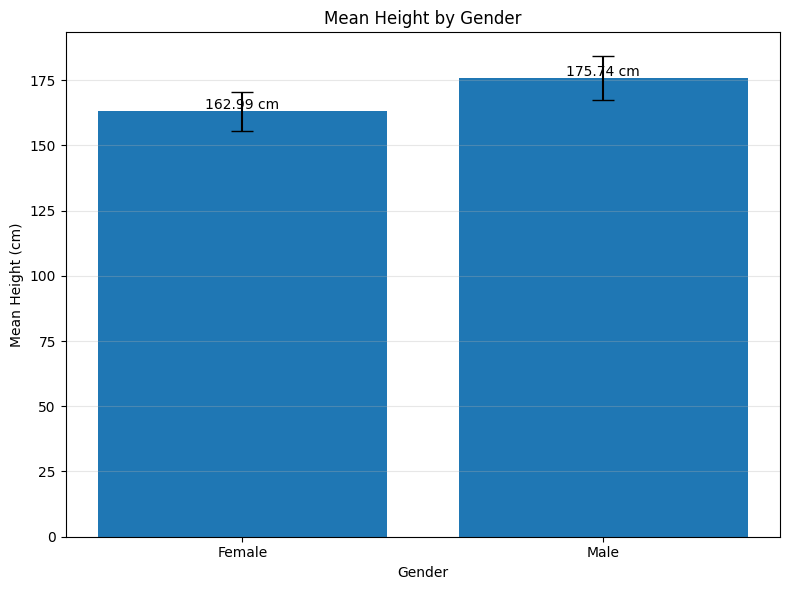

平均身高長條圖已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\figures\mean_height_by_gender.png


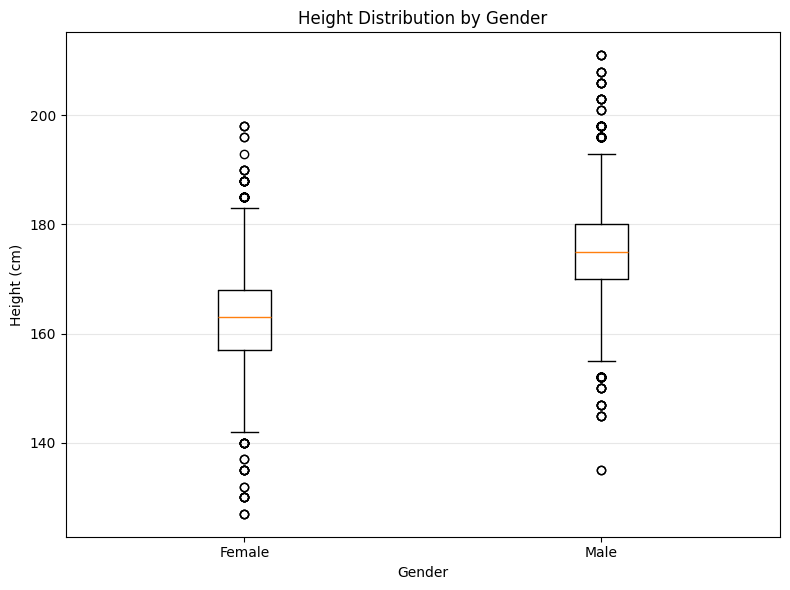

身高箱型圖已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\figures\height_boxplot_by_gender.png


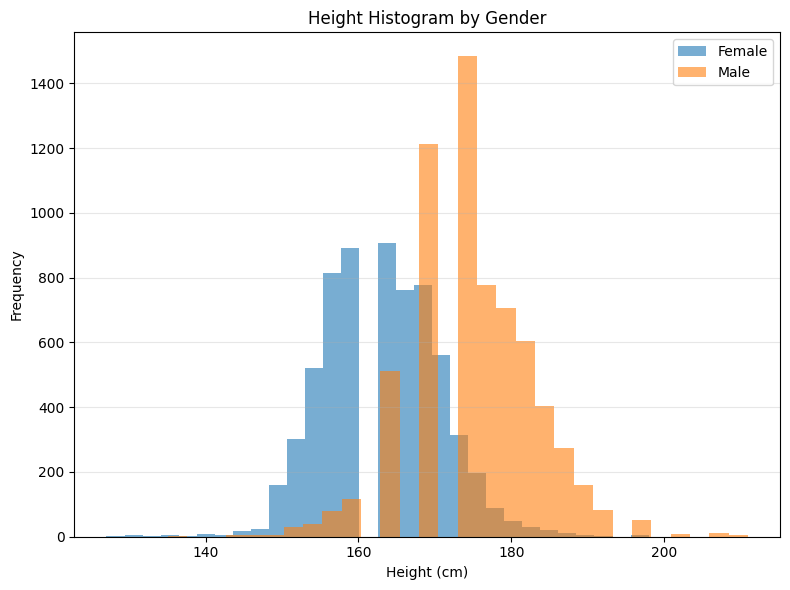

身高直方圖已輸出到：
C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs\figures\height_histogram_by_gender.png
描述性統計結論：
Female mean height: 162.99 cm
Male mean height: 175.74 cm
Mean difference, Male - Female: 12.75 cm
Based on descriptive statistics, male students have a higher average height than female students.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# =========================
# 1. 設定資料路徑
# =========================

processed_dir = Path(r"C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\data\data processed")
output_dir = Path(r"C:\Users\curry\OneDrive\桌面\統計實習\project-cycle-3\outputs")

input_file = processed_dir / "YRBS_2007_cleaned_gender_height.csv"

# 建立輸出資料夾
tables_dir = output_dir / "tables"
figures_dir = output_dir / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("讀取資料：", input_file)
print("輸出資料夾：", output_dir)


# =========================
# 2. 讀取清理後資料
# =========================

df = pd.read_csv(input_file)

print("資料筆數與欄位數：", df.shape)
display(df.head())


# =========================
# 3. 檢查欄位與資料型態
# =========================

required_columns = ["Sex", "Height_m"]

for col in required_columns:
    if col not in df.columns:
        raise ValueError(f"資料中缺少必要欄位：{col}")

# 只保留本次分析需要的欄位
df = df[required_columns].copy()

# 刪除缺失值
df = df.dropna(subset=["Sex", "Height_m"])

# 確保只保留 Female 和 Male
df = df[df["Sex"].isin(["Female", "Male"])].copy()

# 確保身高為數值型態
df["Height_m"] = pd.to_numeric(df["Height_m"], errors="coerce")
df = df.dropna(subset=["Height_m"])

print("清理後可用資料筆數：", df.shape[0])
print("\n各組樣本數：")
print(df["Sex"].value_counts())


# =========================
# 4. 建立描述性統計表
# =========================

summary_table = df.groupby("Sex")["Height_m"].agg(
    n="count",
    mean_height_m="mean",
    std_height_m="std",
    min_height_m="min",
    q1_height_m=lambda x: x.quantile(0.25),
    median_height_m="median",
    q3_height_m=lambda x: x.quantile(0.75),
    max_height_m="max"
).reset_index()

# 新增公分單位，方便報告解釋
summary_table["mean_height_cm"] = summary_table["mean_height_m"] * 100
summary_table["std_height_cm"] = summary_table["std_height_m"] * 100
summary_table["min_height_cm"] = summary_table["min_height_m"] * 100
summary_table["median_height_cm"] = summary_table["median_height_m"] * 100
summary_table["max_height_cm"] = summary_table["max_height_m"] * 100

# 四捨五入，讓表格更清楚
summary_table = summary_table.round(4)

print("描述性統計表：")
display(summary_table)


# =========================
# 5. 輸出描述性統計表
# =========================

summary_output_file = tables_dir / "gender_height_descriptive_summary.csv"
summary_table.to_csv(summary_output_file, index=False, encoding="utf-8-sig")

print("描述性統計表已輸出到：")
print(summary_output_file)


# =========================
# 6. 圖一：男女平均身高長條圖
# =========================

mean_table = summary_table[["Sex", "mean_height_cm", "std_height_cm"]].copy()

plt.figure(figsize=(8, 6))
plt.bar(mean_table["Sex"], mean_table["mean_height_cm"], yerr=mean_table["std_height_cm"], capsize=8)
plt.title("Mean Height by Gender")
plt.xlabel("Gender")
plt.ylabel("Mean Height (cm)")
plt.grid(axis="y", alpha=0.3)

for index, row in mean_table.iterrows():
    plt.text(
        index,
        row["mean_height_cm"] + 1,
        f'{row["mean_height_cm"]:.2f} cm',
        ha="center"
    )

plt.tight_layout()

bar_chart_file = figures_dir / "mean_height_by_gender.png"
plt.savefig(bar_chart_file, dpi=300, bbox_inches="tight")
plt.show()

print("平均身高長條圖已輸出到：")
print(bar_chart_file)


# =========================
# 7. 圖二：男女身高箱型圖
# =========================

female_height_cm = df.loc[df["Sex"] == "Female", "Height_m"] * 100
male_height_cm = df.loc[df["Sex"] == "Male", "Height_m"] * 100

plt.figure(figsize=(8, 6))
plt.boxplot(
    [female_height_cm, male_height_cm],
    labels=["Female", "Male"]
)
plt.title("Height Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Height (cm)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

boxplot_file = figures_dir / "height_boxplot_by_gender.png"
plt.savefig(boxplot_file, dpi=300, bbox_inches="tight")
plt.show()

print("身高箱型圖已輸出到：")
print(boxplot_file)


# =========================
# 8. 圖三：男女身高直方圖
# =========================

plt.figure(figsize=(8, 6))
plt.hist(female_height_cm, bins=30, alpha=0.6, label="Female")
plt.hist(male_height_cm, bins=30, alpha=0.6, label="Male")
plt.title("Height Histogram by Gender")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

histogram_file = figures_dir / "height_histogram_by_gender.png"
plt.savefig(histogram_file, dpi=300, bbox_inches="tight")
plt.show()

print("身高直方圖已輸出到：")
print(histogram_file)


# =========================
# 9. 簡短描述性結論
# =========================

female_mean = summary_table.loc[summary_table["Sex"] == "Female", "mean_height_cm"].values[0]
male_mean = summary_table.loc[summary_table["Sex"] == "Male", "mean_height_cm"].values[0]
difference = male_mean - female_mean

print("描述性統計結論：")
print(f"Female mean height: {female_mean:.2f} cm")
print(f"Male mean height: {male_mean:.2f} cm")
print(f"Mean difference, Male - Female: {difference:.2f} cm")

if difference > 0:
    print("Based on descriptive statistics, male students have a higher average height than female students.")
else:
    print("Based on descriptive statistics, female students have a higher average height than male students.")